In [2]:
from scipy.signal import savgol_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def make_loopable_cycle(data, window_length=200, polyorder=3, overlap_len=50):
    """
    :param data: (T, D) gait sequence (T time steps, D dimensions)
    :param window_length: smoothing window length (should be odd and > polyorder)
    :param polyorder: smoothing polynomial degree
    :param overlap_len: how many frames to overlap head-tail
    """
    assert len(data.shape) == 2  # (T, D)
    T, D = data.shape

    # Step 1: connect tail and head with some overlap
    head = data[:overlap_len]
    tail = data[-overlap_len:]
    extended = np.concatenate([tail, data, head], axis=0)  # shape: (T + 2 * overlap_len, D)

    # Step 2: smooth the extended trajectory
    smoothed = savgol_filter(extended, window_length=window_length, polyorder=polyorder, axis=0)

    # Step 3: trim back to original length, centered to avoid boundary artifacts
    start = overlap_len
    end = overlap_len + T
    loopable = smoothed[start:end]

    return loopable

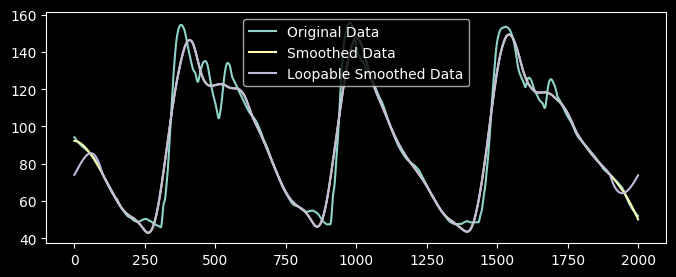

In [68]:
data = pd.read_csv('env/Animal06_110919_00_31.csv', header=[0])
data = data.iloc[:2000, :]

smoothed = savgol_filter(data, window_length=200, polyorder=3, axis=0)
smoothed_data = pd.DataFrame(smoothed, columns=data.columns)

loopable = make_loopable_cycle(data.values, window_length=200, polyorder=3, overlap_len=100)
loopable_data = pd.DataFrame(loopable, columns=data.columns)

plt.figure(figsize=(8, 3))
plt.plot(data['LF_FTi'], label='Original Data')
plt.plot(smoothed_data['LF_FTi'], label='Smoothed Data')
plt.plot(loopable_data['LF_FTi'], label='Loopable Smoothed Data')
plt.legend()
plt.show()


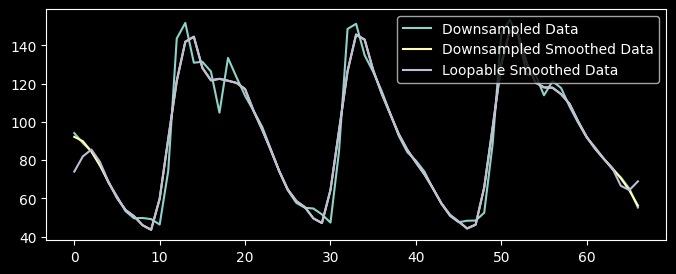

In [73]:
downsampled = np.array(data)[::30]
downsampled_data = pd.DataFrame(downsampled, columns=data.columns)

downsampled_smoothed = smoothed[::30]
downsampled_smoothed_data = pd.DataFrame(downsampled_smoothed, columns=data.columns)

downsampled_loopable = loopable[::30]
downsampled_loopable_data = pd.DataFrame(downsampled_loopable, columns=data.columns)

plt.figure(figsize=(8, 3))
plt.plot(downsampled_data['LF_FTi'], label='Downsampled Data')
plt.plot(downsampled_smoothed_data['LF_FTi'], label='Downsampled Smoothed Data')
plt.plot(downsampled_loopable_data['LF_FTi'], label='Loopable Smoothed Data')
plt.legend()
plt.show()

In [47]:
downsampled_smoothed_data.to_csv('env/ds_sm.csv', index=False)

In [ ]:
downsampled_loopable_data.to_csv('env/ds_loopsm.csv', index=False)

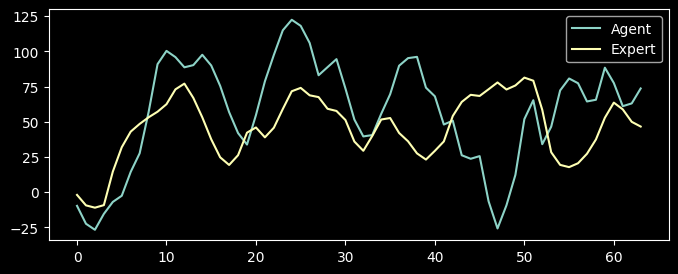

In [3]:
import sys

folder_path = "/home/yuchen/airl-insect-walking/logs/Medauroidea_66k_aug3c/airl_logit_vx/20251007-1539/eval/step90000"
agent_vel_path = f"{folder_path}/episode_5_velocities.csv"
expert_vel_path = f"{folder_path}/expert_velocities.csv"

agent_vel = pd.read_csv(agent_vel_path, header=None)
expert_vel = pd.read_csv(expert_vel_path, header=None)

plt.figure(figsize=(8, 3))
plt.plot(agent_vel[:len(expert_vel)], label='Agent')
plt.plot(expert_vel, label='Expert')
plt.legend()
plt.show()
